In [1]:
# Core libraries:
import numpy as np
import pandas as pd

# Visualization:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Model selection:
from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    cross_validate
)

# Preprocessing:
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

# Pipeline:
from sklearn.pipeline import Pipeline

# Metrics:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Models:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

Subjects shared across all three datasets: 1083

══════════════════════════════════════════════════════════════════════
  DATASET: Coupling   |  features: 7  |  samples: 1083
  Class balance — 0: 684   1: 399
══════════════════════════════════════════════════════════════════════
  Train: 866  |  Test: 217

  ── KNN ──
     CV  acc=0.6557±0.0310  prec=0.6433  rec=0.6557  f1=0.6433
     TEST acc=0.6359  prec=0.6248  rec=0.6359  f1=0.6281
              precision    recall  f1-score   support

     NORMCOG       0.69      0.76      0.72       137
    DEMENTED       0.51      0.42      0.46        80

    accuracy                           0.64       217
   macro avg       0.60      0.59      0.59       217
weighted avg       0.62      0.64      0.63       217


  ── Decision Tree ──
     CV  acc=0.6056±0.0330  prec=0.6076  rec=0.6056  f1=0.6056
     TEST acc=0.5899  prec=0.5975  rec=0.5899  f1=0.5931
              precision    recall  f1-score   support

     NORMCOG       0.68      0.65  

NameError: name 'a' is not defined

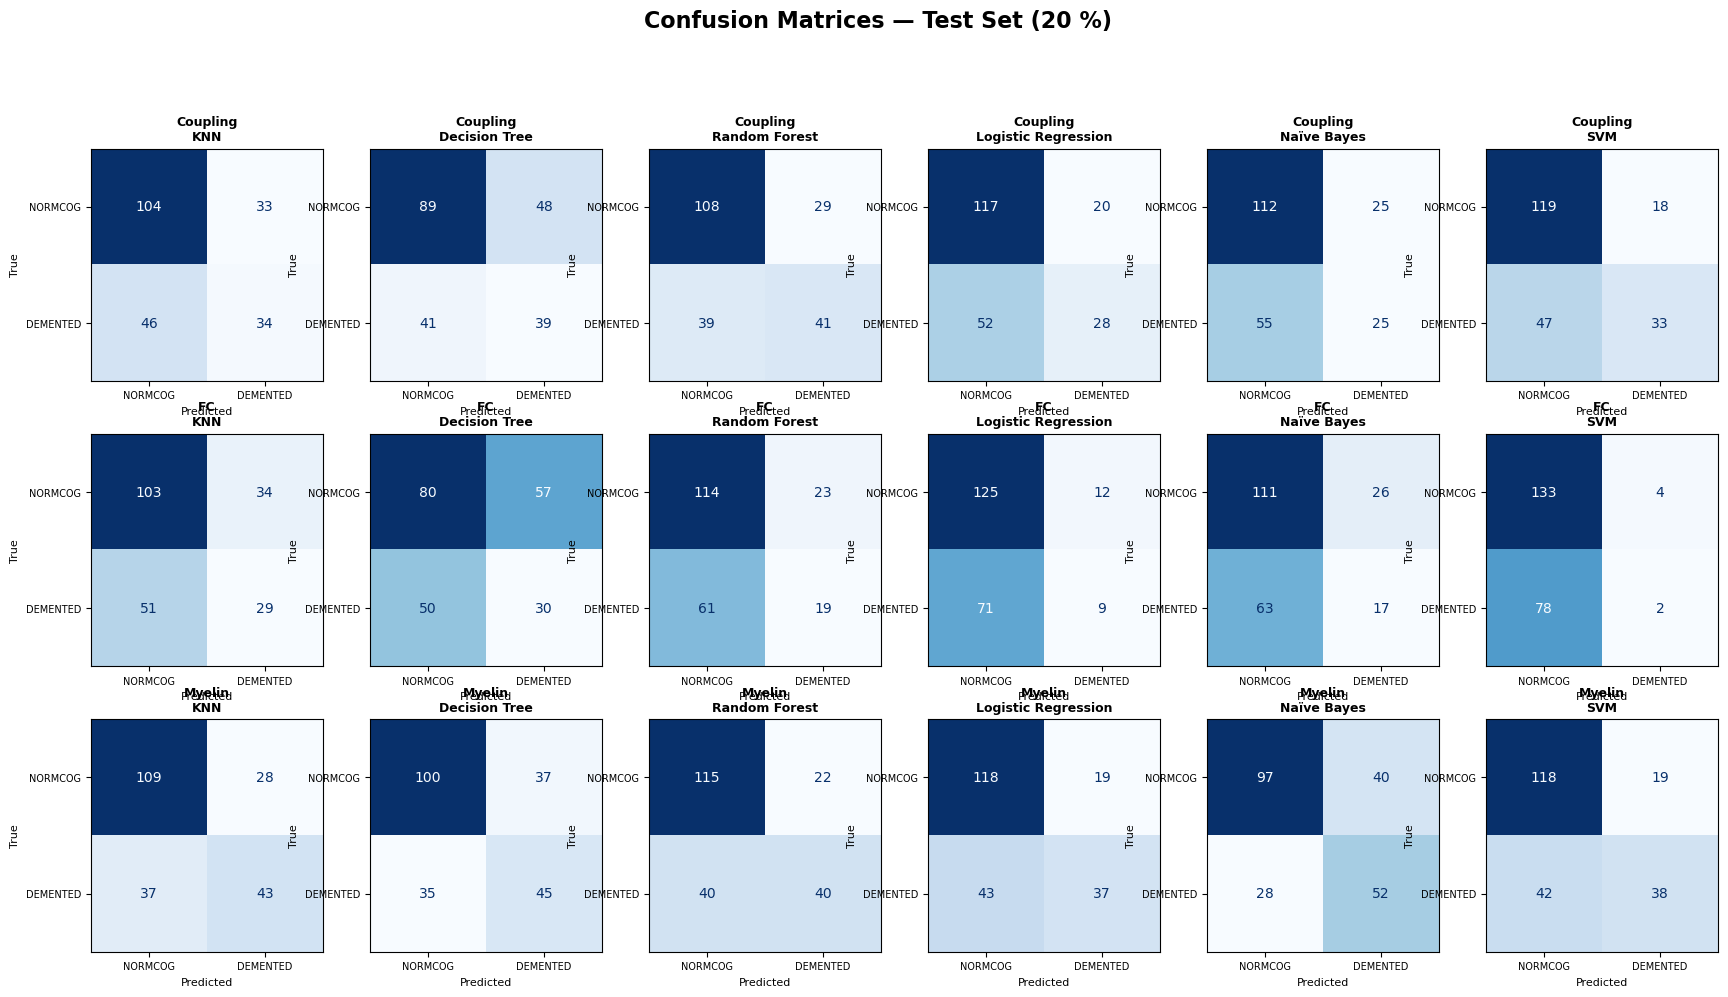

In [2]:
# Define reproducibility seed:
SEED = 34

### Load Data ###

# Load myelin-FC coupling vectors (one row per subject)
df_coupling = pd.read_csv("Myelin_FC_coupling_vectors.csv")
 
# Load FC metrics; keep only the first 2 columns and the last 7 feature columns:
df_fc = pd.read_csv("../FC/fc_metrics.csv")
cols_to_keep = list(df_fc.columns[:2]) + list(df_fc.columns[-7:])
df_fc = df_fc[cols_to_keep]
df_fc = df_fc.rename(columns={"Subject ID": "Subject_ID"}) 
 
# Load myelin network features; drop the Age column (not used as a feature):
df_myelin = pd.read_csv("../Myelin/Scripts/myelin_features_networks_filtered.csv")
df_myelin = df_myelin.drop(columns=["Age"])
 
# Move 'group' column to position 1 (right after Subject_ID) for clarity:
cols = list(df_myelin.columns)
cols.insert(1, cols.pop(cols.index("group")))
df_myelin = df_myelin[cols]
 
# Ensure Subject_ID is a string in all three frames:
df_coupling["Subject_ID"] = df_coupling["Subject_ID"].astype(str)
df_fc["Subject_ID"] = df_fc["Subject_ID"].astype(str)
df_myelin["Subject_ID"] = df_myelin["Subject_ID"].astype(str)
 
# Keep only subjects present in ALL three datasets:
common_ids = (set(df_coupling["Subject_ID"]).intersection(df_fc["Subject_ID"]).intersection(df_myelin["Subject_ID"]))
print(f"Subjects shared across all three datasets: {len(common_ids)}")
df_coupling = df_coupling[df_coupling["Subject_ID"].isin(common_ids)].copy()
df_fc       = df_fc[df_fc["Subject_ID"].isin(common_ids)].copy()
df_myelin   = df_myelin[df_myelin["Subject_ID"].isin(common_ids)].copy()
 
# Define a helper function that prepares features (X) and labels (y) from a dataframe:
def prepare_XY(df, label_col="group"):
    # Remove the subject ID column and label column from the feature set:
    X = df.drop(columns=["Subject_ID", label_col], errors="ignore")

    # Keep only numeric columns to ensure the model receives numerical features:
    X = X.select_dtypes(include=[np.number])
    
    # Extract the target/label column:
    y_raw = df[label_col]
    
    # Try converting labels directly to 64-bit integers:
    try:
        y = np.array(y_raw, dtype=np.int64)

    # If labels are strings or other non-numeric types, encode them:
    except (ValueError, TypeError):
        # Explicit mapping: normcog=0, demented=1
        mapping = {"normcog": 0, "demented": 1}
        
        # Normalize to lowercase to handle case variations:
        y = np.array([mapping[v.lower()] for v in y_raw.astype(str)])

    # Return:
    #   X as a NumPy array of float64 features
    #   y as a NumPy array of int64 labels
    return np.array(X, dtype=np.float64), np.array(y, dtype=np.int64)


# Prepare coupling, FC and myelin datasets (X and y):
X_coup, y_coup = prepare_XY(df_coupling)
X_fc, y_fc = prepare_XY(df_fc)
X_mye, y_mye = prepare_XY(df_myelin)

# Bundle datasets into a dict for the loop:
datasets = {
    "Coupling": (X_coup, y_coup),
    "FC":       (X_fc,   y_fc),
    "Myelin":   (X_mye,  y_mye),
}

### Define Classifier Models ###
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naïve Bayes": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=SEED),
}

classifiers = {
    name: Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    for name, model in models.items()
}

### Cross-Validation Setp-Up ### 
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
 
# Scoring metrics for cross validation:
scoring = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]
 
### Main Loop: For each dataset: Split, CV on train and evaluate on test:
 
# Containers for summary tables
all_cv_rows = [] # Cross-validation summary.
all_test_rows = [] # Held-out test set metrics.
 
# We will build a big figure with confusion matrices at the end
# Layout: 3 datasets × 6 models = 18 confusion matrix panels
n_datasets = len(datasets)
n_models = len(classifiers)
fig_cm, axes_cm = plt.subplots(n_datasets, n_models, figsize=(n_models * 3.5, n_datasets * 3.5))
fig_cm.suptitle("Confusion Matrices — Test Set (20 %)", fontsize=16, fontweight="bold", y=1.01)

# Iterate over each of the myelin, FC and Coupling datasets:
for d_idx, (ds_name, (X, y)) in enumerate(datasets.items()):
 
    print(f"\n{'═'*70}")
    print(f"  DATASET: {ds_name}   |  features: {X.shape[1]}  |  samples: {X.shape[0]}")
    print(f"  Class balance — 0: {(y==0).sum()}   1: {(y==1).sum()}")
    print(f"{'═'*70}")
 
    # Perform 80 / 20 stratified split:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
    print(f"  Train: {len(y_train)}  |  Test: {len(y_test)}")

    # Iterate over each classifier type:
    for m_idx, (clf_name, pipeline) in enumerate(classifiers.items()):
 
        # Repeated Stratified K-Fold CV on training set:
        cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

        # Compute mean ± std for each metric across all 50 folds
        cv_acc = cv_results["test_accuracy"]
        cv_prec = cv_results["test_precision_weighted"]
        cv_rec = cv_results["test_recall_weighted"]
        cv_f1 = cv_results["test_f1_weighted"]

        all_cv_rows.append({
            "Dataset":   ds_name,
            "Model":     clf_name,
            "CV Acc (mean)":  f"{cv_acc.mean():.4f}",
            "CV Acc (std)":   f"{cv_acc.std():.4f}",
            "CV Prec (mean)": f"{cv_prec.mean():.4f}",
            "CV Rec (mean)":  f"{cv_rec.mean():.4f}",
            "CV F1 (mean)":   f"{cv_f1.mean():.4f}",
        })

        # Fit on full training set and evaluate on held-out test set:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
 
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        all_test_rows.append({
            "Dataset":   ds_name,
            "Model":     clf_name,
            "Accuracy":  round(acc,  4),
            "Precision": round(prec, 4),
            "Recall":    round(rec,  4),
            "F1-Score":  round(f1,   4),
        })
        
        # Show results:
        print(f"\n  ── {clf_name} ──")
        print(f"     CV  acc={cv_acc.mean():.4f}±{cv_acc.std():.4f}  "f"prec={cv_prec.mean():.4f}  rec={cv_rec.mean():.4f}  f1={cv_f1.mean():.4f}")
        print(f"     TEST acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=["NORMCOG","DEMENTED"], zero_division=0))

        # Confusion matrix panel:
        ax = axes_cm[d_idx, m_idx]
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["NORMCOG","DEMENTED"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{ds_name}\n{clf_name}", fontsize=9, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=8)
        ax.set_ylabel("True",      fontsize=8)
        ax.tick_params(labelsize=7)
a
# Save the confusion matrix figure:
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
print("\nSaved → confusion_matrices.png")
 
# Create summary tables:
 
df_cv = pd.DataFrame(all_cv_rows)
df_test = pd.DataFrame(all_test_rows)
 
print("\n")
print("╔══════════════════════════════════════════════════════════════════╗")
print("║      REPEATED STRATIFIED K-FOLD CV SUMMARY (5 folds × 10 reps)  ║")
print("╚══════════════════════════════════════════════════════════════════╝")
print(df_cv.to_string(index=False))
 
print("\n")
print("╔═══════════════════════════════════════════════════╗")
print("║      HELD-OUT TEST SET METRICS (20 % split)       ║")
print("╚═══════════════════════════════════════════════════╝")
print(df_test.to_string(index=False))
 
# Save both tables to CSV
df_cv.to_csv("cv_summary.csv",   index=False)
df_test.to_csv("test_metrics.csv", index=False)
print("\nSaved → cv_summary.csv")
print("Saved → test_metrics.csv")
 
# ═════════════════════════════════════════════════════════════════════════════
# 7. BAR-CHART COMPARISON (test-set F1) — one panel per dataset
# ═════════════════════════════════════════════════════════════════════════════
 
fig_bar, axes_bar = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 5), sharey=True)
fig_bar.suptitle("Test-Set F1-Score by Model and Dataset",
                 fontsize=14, fontweight="bold")
 
# colour palette — one colour per metric
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
palette = sns.color_palette("tab10", len(metrics_to_plot))
 
for ax, ds_name in zip(axes_bar, datasets.keys()):
    sub = df_test[df_test["Dataset"] == ds_name].copy()
    x   = np.arange(len(sub))
    bar_w = 0.18
 
    for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
        ax.bar(x + i * bar_w, sub[metric], width=bar_w,
               label=metric, color=color, edgecolor="white", linewidth=0.5)
 
    ax.set_xticks(x + bar_w * (len(metrics_to_plot) - 1) / 2)
    ax.set_xticklabels(sub["Model"], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.savefig("test_metrics_barplot.png", dpi=150, bbox_inches="tight")
print("Saved → test_metrics_barplot.png")
 
plt.show()
print("\nDone.")